Using device: cuda
Elapsed time: 0.00396418571472168


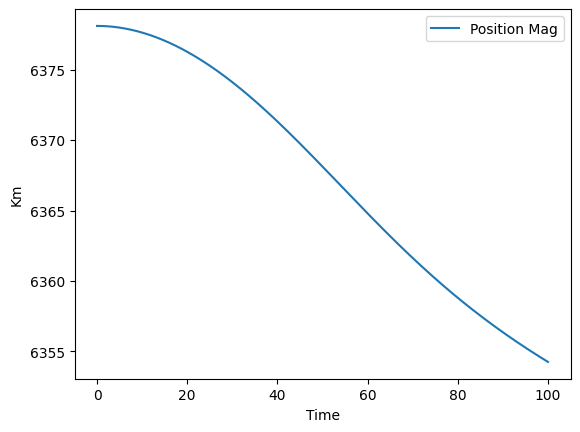

In [10]:
import torch
import torchdiffeq as diffeq
import orbitengine.engine as oe
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from astropy import units as u
import numpy as np

#check if cuda is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

#on ground
r0 = np.array([oe.EARTH_RADIUS_KM, 0, 0])*u.km
v0 = np.array([0, oe.EARTH_RADIUS_KM*2*np.pi/(24*3600) , 0])*u.km/u.s
k = oe.EARTH_K.value
m0 = 100000*u.kg # rocket + fuel
T0 = oe.TEMP_EARTH
isp = oe.SPECIFIC_IMPULSE_TYPE.Liquid
flow = oe.FALCON9_REACTION_MASS_FLOW_RATE

u0 = torch.tensor([*r0.value, *v0.value, m0.value, T0.value])  # Initial state
y0 = [*r0.value, *v0.value, m0.value, T0.value]  # Initial state

t_span = torch.linspace(0.01, 100., 500)

acc_params = oe.AccParams()
acc_params.thrust_vec = torch.tensor([1., 0., 0.])

# Solve the using trochdifeq
#solution = diffeq.odeint(lotka_volterra, u0, t_span, args=()method='dopri5')
import time
ts_start = time.time()
use_torchdiffeq = False
if use_torchdiffeq:
    solution = diffeq.odeint(lambda y,t: oe.twobody(y, t, k, acc_params), u0, t_span, method='dopri5')
    position = solution[:, :3]
    r = torch.norm(position, dim=1)

else:
    # Using odeint
    solution = odeint(oe.twobody_ode, u0, t_span, args=(k, acc_params))
    position = solution[:, :3]
    r = np.linalg.norm(position, axis=1)
ts_stop = time.time()

print(f'Elapsed time: {ts_stop-ts_start}')

plt.plot(t_span, r, label='Position Mag')
plt.xlabel('Time')
plt.ylabel('Km')
plt.legend()
plt.show()



In [ ]:

solution = odeint(twobody_ode, u0, t_span, args=(k, acc_params))
position = solution[-1, :3]
print(position)

# Using odeint
t= 100
solution = odeint(twobody_ode, u0, [t], args=(k, acc_params))
position = solution[-1, :3]
print(position)